# Aufgabe 4 — Datenbereinigung & Vorbereitung

**CRISP-DM-Phase: Data Preparation**  
**Projekt:** Basket Trading using Bayesian Optimization  
**Autor:** Nassim Groppe

Schritte: Fehlwert-Analyse → Ausreißer-Detektion → Forward-Fill → Feature Engineering → Speicherung.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")

RAW_DIR       = Path.home() / "Desktop/DBU_Data_Analyst_I/data/raw"
PROCESSED_DIR = Path.home() / "Desktop/DBU_Data_Analyst_I/data/processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
prices_df       = pd.read_parquet(RAW_DIR / "dax_mdax_prices_2019_2025.parquet")
fundamentals_df = pd.read_csv(RAW_DIR / "dax_mdax_fundamentals.csv")

print(f"Preisdaten:       {prices_df.shape}")
print(f"Fundamentaldaten: {fundamentals_df.shape}")
print(f"Ticker: {prices_df['ticker'].nunique()}")
print(f"Zeitraum: {prices_df['date'].min()} bis {prices_df['date'].max()}")

Preisdaten:       (150489, 9)
Fundamentaldaten: (89, 12)
Ticker: 86
Zeitraum: 2019-01-02 00:00:00 bis 2025-12-30 00:00:00


## 1. Fehlwert-Analyse

In [ ]:
print("=== Fehlwert-Analyse: Preisdaten ===")
missing_prices = prices_df.isnull().sum()
missing_pct    = (prices_df.isnull().sum() / len(prices_df) * 100).round(2)
print(pd.DataFrame({"fehlend": missing_prices, "anteil_%": missing_pct}))

print(f"\nGesamtzeilen: {len(prices_df):,}")
print(f"Ticker gesamt: {prices_df['ticker'].nunique()}")

print("\n=== Fehlwert-Analyse: Fundamentaldaten ===")
missing_fund     = fundamentals_df.isnull().sum()
missing_fund_pct = (fundamentals_df.isnull().sum() / len(fundamentals_df) * 100).round(2)
print(pd.DataFrame({"fehlend": missing_fund, "anteil_%": missing_fund_pct}))

=== Fehlwert-Analyse: Preisdaten ===
            fehlend  anteil_%
date              0       0.0
ticker            0       0.0
adj_close    150489     100.0
close             0       0.0
high              0       0.0
low               0       0.0
open              0       0.0
volume            0       0.0
index_name        0       0.0

Gesamtzeilen: 150,489
Ticker gesamt: 86

=== Fehlwert-Analyse: Fundamentaldaten ===
                fehlend  anteil_%
ticker                0      0.00
index_name            0      0.00
full_name             2      2.25
market_cap            3      3.37
pe_ratio             14     15.73
dividend_yield       10     11.24
sector                3      3.37
industry              3      3.37
currency              3      3.37
country               3      3.37
employees            89    100.00
price_to_book         3      3.37


## 2. Ausreißer-Detektion

Ausreißer (1%/99%-Quantil): 3,010 Zeilen (2.00%)

Extremste Tagesrenditen (negativ):
      date  ticker     close  daily_return
2024-03-08  HFG.DE  6.858000     -0.421022
2023-01-31  VH2.DE 12.206151     -0.374374
2023-06-23  ENR.DE 14.587791     -0.373396
2023-10-26  ENR.DE  6.840828     -0.354930
2024-08-07  EVT.DE  5.445000     -0.346339
2024-04-24  EVT.DE  9.640000     -0.320169
2022-02-10 DHER.DE 46.490002     -0.304458
2025-10-13  TKA.DE  9.553561     -0.256645
2025-09-10  CON.DE 55.358364     -0.255736
2019-12-18 JUN3.DE 17.418833     -0.251138


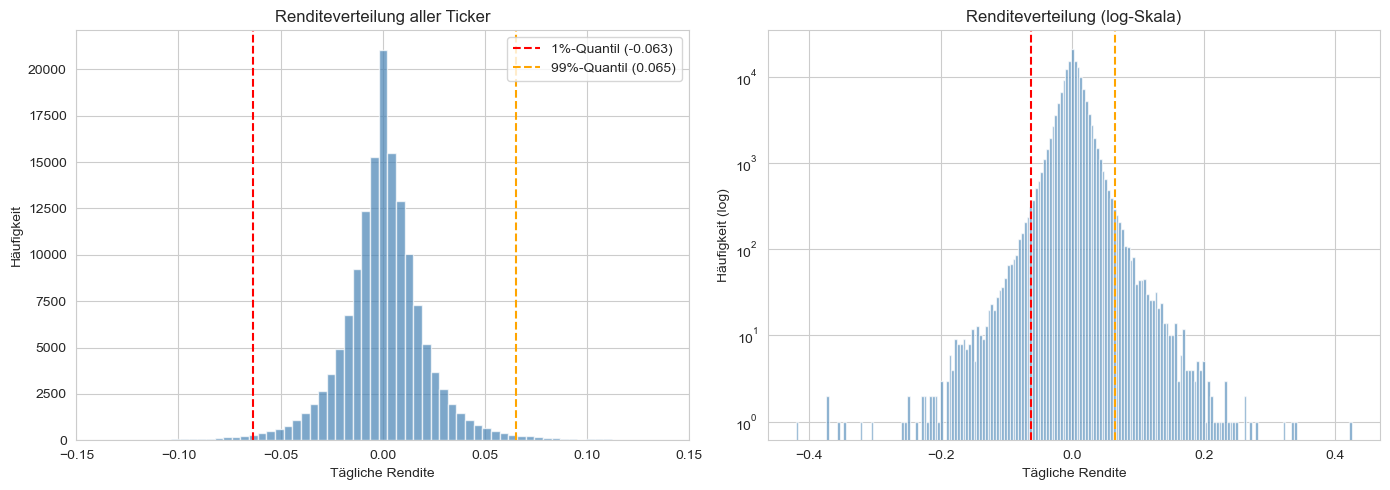

In [ ]:
prices_df = prices_df.sort_values(["ticker", "date"])
prices_df["daily_return"] = prices_df.groupby("ticker")["close"].pct_change()

q1  = prices_df["daily_return"].quantile(0.01)
q99 = prices_df["daily_return"].quantile(0.99)
outlier_mask = (prices_df["daily_return"] < q1) | (prices_df["daily_return"] > q99)

print(f"Ausreißer (1%/99%-Quantil): {outlier_mask.sum():,} Zeilen ({outlier_mask.mean()*100:.2f}%)")
print("\nExtremste Tagesrenditen (negativ):")
print(
    prices_df.loc[outlier_mask & (prices_df["daily_return"] < q1),
                  ["date", "ticker", "close", "daily_return"]]
    .sort_values("daily_return").head(10).to_string(index=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(prices_df["daily_return"].dropna(), bins=200, color="steelblue", alpha=0.7)
axes[0].axvline(q1,  color="red",    linestyle="--", label=f"1%-Quantil ({q1:.3f})")
axes[0].axvline(q99, color="orange", linestyle="--", label=f"99%-Quantil ({q99:.3f})")
axes[0].set_xlim(-0.15, 0.15)
axes[0].set_xlabel("Tägliche Rendite")
axes[0].set_ylabel("Häufigkeit")
axes[0].set_title("Renditeverteilung aller Ticker")
axes[0].legend()

axes[1].hist(prices_df["daily_return"].dropna(), bins=200, color="steelblue", alpha=0.7)
axes[1].axvline(q1,  color="red",    linestyle="--")
axes[1].axvline(q99, color="orange", linestyle="--")
axes[1].set_xlabel("Tägliche Rendite")
axes[1].set_ylabel("Häufigkeit (log)")
axes[1].set_title("Renditeverteilung (log-Skala)")
axes[1].set_yscale("log")
plt.tight_layout()
plt.show()

## 3. Forward-Fill für Preisdaten

Fehlende Kurse entstehen durch Börsenfeiertage oder Handelsaussetzungen.  
Forward-Fill überträgt den letzten bekannten Kurs (max. 5 Handelstage).

In [ ]:
prices_before = prices_df["close"].isnull().sum()

for col in ["open", "high", "low", "close", "adj_close"]:
    prices_df[col] = (
        prices_df.groupby("ticker")[col]
        .transform(lambda s: s.ffill(limit=5))
    )

prices_after = prices_df["close"].isnull().sum()
print(f"Fehlende close-Werte vor  Forward-Fill: {prices_before:,}")
print(f"Fehlende close-Werte nach Forward-Fill: {prices_after:,}")
print(f"Aufgefüllt: {prices_before - prices_after:,} Zeilen")

prices_df["daily_return"] = prices_df.groupby("ticker")["close"].pct_change()

Fehlende close-Werte vor  Forward-Fill: 0
Fehlende close-Werte nach Forward-Fill: 0
Aufgefüllt: 0 Zeilen


## 4. Feature Engineering

> Transformationen und Feature Engineering erst nach Modellarchitektur-Entscheidung (vgl. Skript Ambach).

In [ ]:
prices_df["log_return"] = np.log(
    prices_df.groupby("ticker")["close"]
    .transform(lambda s: s / s.shift(1))
)

prices_df["volume_zscore"] = (
    prices_df.groupby("ticker")["volume"]
    .transform(lambda s: (s - s.mean()) / s.std())
)

print(f"Shape nach Feature Engineering: {prices_df.shape}")
print(prices_df[["ticker", "date", "close", "daily_return", "log_return", "volume_zscore"]].head(8).to_string(index=False))

Shape nach Feature Engineering: (150489, 12)
 ticker       date     close  daily_return  log_return  volume_zscore
8TRA.DE 2019-07-01 20.949963           NaN         NaN      11.278037
8TRA.DE 2019-07-02 21.300375      0.016726    0.016588       2.854364
8TRA.DE 2019-07-03 21.363369      0.002957    0.002953       3.217783
8TRA.DE 2019-07-04 21.473614      0.005160    0.005147       1.561269
8TRA.DE 2019-07-05 21.170444     -0.014118   -0.014219       1.047015
8TRA.DE 2019-07-08 21.225569      0.002604    0.002600       0.739043
8TRA.DE 2019-07-09 20.709791     -0.024300   -0.024600       0.829358
8TRA.DE 2019-07-10 20.985395      0.013308    0.013220       0.560415


## 5. Speicherung nach data/processed/

In [ ]:
out_prices = PROCESSED_DIR / "prices_cleaned.parquet"
out_fund   = PROCESSED_DIR / "fundamentals_cleaned.csv"

prices_df.to_parquet(out_prices, index=False)
fundamentals_df.to_csv(out_fund, index=False, encoding="utf-8-sig")

print(f"Gespeichert: {out_prices}  ({out_prices.stat().st_size / 1e6:.2f} MB)")
print(f"Gespeichert: {out_fund}  ({out_fund.stat().st_size / 1e3:.1f} KB)")
print(f"\nBereinigte Preisdaten: {len(prices_df):,} Zeilen, {prices_df['ticker'].nunique()} Ticker")
print(f"Fehlende close-Werte nach Bereinigung: {prices_df['close'].isnull().sum()}")

Gespeichert: /Users/lisagroppe/Desktop/DBU_Data_Analyst_I/data/processed/prices_cleaned.parquet  (10.82 MB)
Gespeichert: /Users/lisagroppe/Desktop/DBU_Data_Analyst_I/data/processed/fundamentals_cleaned.csv  (10.5 KB)

Bereinigte Preisdaten: 150,489 Zeilen, 86 Ticker
Fehlende close-Werte nach Bereinigung: 0


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from ydata_profiling import ProfileReport
from pathlib import Path

# Ausgabe-Stil
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

PROCESSED_DIR = Path.home() / "Desktop/DBU_Data_Analyst_I/data/processed"
OUTPUTS_DIR   = Path.home() / "Desktop/DBU_Data_Analyst_I/outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

# Bereinigte Daten einlesen
prices_df       = pd.read_parquet(PROCESSED_DIR / "prices_cleaned.parquet")
fundamentals_df = pd.read_csv(PROCESSED_DIR / "fundamentals_cleaned.csv")

print(f"Preisdaten:      {prices_df.shape}")
print(f"Fundamentaldaten: {fundamentals_df.shape}")
prices_df.head(3)

Preisdaten:      (150489, 12)
Fundamentaldaten: (89, 12)


,date,ticker,adj_close,close,high,low,open,volume,index_name,daily_return,log_return,volume_zscore
0,2019-07-01,8TRA.DE,NaN,20.949963,21.221632,20.788537,20.946026,1427241.0,MDAX50,NaN,NaN,11.278037
1,2019-07-02,8TRA.DE,NaN,21.300375,21.402744,20.949962,21.036582,447352.0,MDAX50,0.016726,0.016588,2.854364
2,2019-07-03,8TRA.DE,NaN,21.363369,21.536608,21.292500,21.402742,489627.0,MDAX50,0.002957,0.002953,3.217783


# ydata-profiling Report
Aztomatischer datenporfil-Report für einen schnellen Überblicck pner Verteilungen, Fehlerwerten und Korrelationen.
Export als HTML nach outputs/eda_repoprts.html

In [ ]:
# Stichprobe für Performance (ProfileReport auf dem vollständigen Datensatz kann mehrere Minuten dauern)
sample_df = prices_df.sample(n=min(20_000, len(prices_df)), random_state=42)

profile = ProfileReport(
    sample_df,
    title="DAX 40 + MDAX 50 — EDA Report (Basket Trading)",
    explorative=True,
)

report_path = OUTPUTS_DIR / "eda_report.html"
profile.to_file(report_path)
print(f"Report gespeichert: {report_path}")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:00<00:00, 42.24it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Report gespeichert: /Users/lisagroppe/Desktop/DBU_Data_Analyst_I/outputs/eda_report.html


# 2. Boxplots - Rendite und Volatilität nach Sektor

In [ ]:
# Sektor-Info aus Fundamentaldaten zu Preisdaten joinen
merged = prices_df.merge(
    fundamentals_df[['ticker', 'sector']].dropna(),
    on='ticker', how='left'
)
merged = merged[merged['sector'].notna()]

# 30-Tage-Volatilität je Ticker berechnen
merged = merged.sort_values(['ticker', 'date'])
merged['volatility_30d'] = (
    merged.groupby('ticker')['daily_return']
    .transform(lambda s: s.rolling(30, min_periods=10).std())
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sektoren = merged['sector'].value_counts().index.tolist()
rendite_data  = [merged.loc[merged['sector'] == s, 'daily_return'].dropna() for s in sektoren]
vola_data     = [merged.loc[merged['sector'] == s, 'volatility_30d'].dropna() for s in sektoren]

axes[0].boxplot(rendite_data, labels=sektoren, showfliers=False, patch_artist=True)
axes[0].set_xticklabels(sektoren, rotation=40, ha='right', fontsize=8)
axes[0].set_ylabel("Tägliche Rendite")
axes[0].set_title("Tägliche Rendite nach Sektor")
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)

axes[1].boxplot(vola_data, labels=sektoren, showfliers=False, patch_artist=True)
axes[1].set_xticklabels(sektoren, rotation=40, ha='right', fontsize=8)
axes[1].set_ylabel("Volatilität (30 Tage, annualisierbar)")
axes[1].set_title("30-Tage-Volatilität nach Sektor")

plt.tight_layout()
plt.show()

print(f"Datenbasis: {merged['ticker'].nunique()} Ticker in {merged['sector'].nunique()} Sektoren")


: 

# 3. Scatterplots - Feature Beziehungen

In [ ]:
# Momentum_12M vs. Forward_Return_1M
# Momentum: Rendite der letzten 252 Handelstage
# Forward Return: Rendite der nächsten 21 Handelstage
prices_df_s = prices_df.sort_values(['ticker', 'date'])
prices_df_s['momentum_12m'] = (
    prices_df_s.groupby('ticker')['close']
    .transform(lambda s: s.pct_change(252))
)
prices_df_s['forward_return_1m'] = (
    prices_df_s.groupby('ticker')['close']
    .transform(lambda s: s.shift(-21) / s - 1)
)

scatter_df = prices_df_s[['momentum_12m', 'forward_return_1m']].dropna()
# Auf ±50% begrenzen für Übersichtlichkeit
scatter_df = scatter_df[
    scatter_df['momentum_12m'].between(-0.5, 0.5) &
    scatter_df['forward_return_1m'].between(-0.3, 0.3)
]

plt.figure(figsize=(10, 6))
plt.hexbin(scatter_df['momentum_12m'], scatter_df['forward_return_1m'],
           gridsize=40, cmap='Blues', mincnt=1)
plt.colorbar(label='Anzahl Beobachtungen')
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel("Momentum 12M (Jahresrendite)")
plt.ylabel("Forward Return 1M (Folgerendite)")
plt.title("Momentum 12M vs. Forward Return 1M — Hexbin-Dichte")
plt.tight_layout()
plt.show()

corr = scatter_df.corr().iloc[0, 1]
print(f"Pearson-Korrelation Momentum vs. Forward Return: {corr:.4f}")


In [ ]:
# P_E_Ratio vs. Forward_Return_1M — Fundamentaldaten + Kursdaten
# Letzter verfügbarer Forward Return je Ticker
last_fwd = (
    prices_df_s[['ticker', 'forward_return_1m']]
    .dropna()
    .groupby('ticker')['forward_return_1m']
    .mean()
    .reset_index()
)

pe_fwd = last_fwd.merge(
    fundamentals_df[['ticker', 'pe_ratio']].dropna(),
    on='ticker'
)
pe_fwd = pe_fwd[pe_fwd['pe_ratio'].between(0, 80)]

plt.figure(figsize=(10, 6))
plt.scatter(pe_fwd['pe_ratio'], pe_fwd['forward_return_1m'],
            alpha=0.7, color='steelblue', edgecolors='white', s=60)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel("KGV (P/E Ratio, trailing)")
plt.ylabel("Mittlerer Forward Return 1M")
plt.title("P/E Ratio vs. Forward Return 1M je Ticker")

for _, row in pe_fwd.iterrows():
    plt.annotate(row['ticker'], (row['pe_ratio'], row['forward_return_1m']),
                 fontsize=6, alpha=0.6)

plt.tight_layout()
plt.show()

corr3 = pe_fwd[['pe_ratio', 'forward_return_1m']].corr().iloc[0, 1]
print(f"Ticker im Plot: {len(pe_fwd)}")
print(f"Pearson-Korrelation P/E vs. Forward Return: {corr3:.4f}")


# 4. Korrelationsmatrizen

In [ ]:
# Feature-Korrelationen mit Heatmap (Multikollinearitätsprüfung)
feature_cols = ['daily_return', 'log_return', 'volume_zscore',
                'momentum_12m', 'volatility_30d', 'forward_return_1m']

feat_df = prices_df_s[feature_cols].dropna()
corr_matrix = feat_df.corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1,
    xticklabels=feature_cols, yticklabels=feature_cols,
    linewidths=0.5
)
plt.title("Feature-Korrelationsmatrix (Pearson)")
plt.tight_layout()
plt.show()

print("Korrelationsmatrix:")
print(corr_matrix.round(3))



In [ ]:
# Asset-Korrelationsmatrix (Schlusskurse — Basis für Diversifikations-Clustering)
# Pivot: Zeilen = Datum, Spalten = Ticker, Werte = Tagesrendite
price_pivot = prices_df_s.pivot_table(
    index='date', columns='ticker', values='daily_return'
)

# Nur Ticker mit genug Daten behalten
price_pivot = price_pivot.dropna(thresh=int(len(price_pivot) * 0.8), axis=1)
asset_corr  = price_pivot.corr()

plt.figure(figsize=(18, 15))
sns.heatmap(
    asset_corr,
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    xticklabels=True, yticklabels=True,
    linewidths=0.1, annot=False
)
plt.title("Asset-Korrelationsmatrix — Tagesrenditen (DAX40 + MDAX50)")
plt.xticks(fontsize=6, rotation=90)
plt.yticks(fontsize=6, rotation=0)
plt.tight_layout()
plt.show()

# Mittlere Paarkorrelation als Diversifikationsmaß
mean_corr = asset_corr.where(
    ~np.eye(len(asset_corr), dtype=bool)
).stack().mean()
print(f"Mittlere Paarkorrelation: {mean_corr:.4f}")
print(f"(Niedrigerer Wert = bessere Diversifikationsbasis)")
    